# 问题一优化版：时间优先的精确组批与论文图表

覆盖四项任务。保留原Q1.ipynb；本Notebook调用经过核验的脚本，不维护重复模型。全部输入为正式附件。累计作业时间≠多机并行完工时间。详见README.md及论文第六章。

In [1]:
from pathlib import Path
import sys, subprocess, json
import pandas as pd
from IPython.display import display, Image
HERE=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'analyze.py').exists()) if (Path.cwd()/'analyze.py').exists() else next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'26-Modeling').exists())/'26-Modeling/002-Code/Optimize/Q1/Q1-Code'
R=HERE/'results'
def run(name):
    r=subprocess.run([sys.executable,str(HERE/name)],cwd=HERE,capture_output=True,text=True)
    if r.returncode: raise RuntimeError(r.stdout+r.stderr)
    print(name, '完成')

## 1 模型与求解
按原始DEM构建航段；以单调能耗求最大安全载荷，再枚举机型—箱数模式。有限剩余需求状态上的Pareto递推保留非支配目标向量，跨区以可加目标合成完整前沿。

In [2]:
run('analyze.py')
run('verify.py')
display(pd.read_csv(R/'qmax.csv',index_col=0).round(3))
print((R/'verification.json').read_text())

analyze.py 完成


verify.py 完成


,A,B,C
S001,25.0,30.000,80.000
S002,25.0,30.000,68.860
S003,25.0,30.000,68.206
S004,25.0,30.000,63.697
S005,25.0,30.000,80.000
S006,25.0,30.000,80.000
S007,25.0,30.000,80.000
S008,25.0,28.801,58.904
S009,25.0,30.000,80.000
S010,25.0,30.000,80.000


{
  "geometry_routes_checked": 15,
  "payload_roots_checked": 45,
  "DP_states_checked_against_quadratic_dominance": 629,
  "status": "passed"
}


## 2 从 Pareto 前沿到决策：时间优先、权衡与局部替换

R1=N→E→T；R2=E→N→T；**R3=T→N→E（推荐）**；R4=全局理想值归一化等权。推荐表达累计作业投入的偏好，不推断时限达成或后续资源周转收益。

多个规则选中同点不等于不存在冲突，应检查完整前沿。两个前沿点仅在S008有区别：C型一次45kg与B型两次25+20kg。

In [3]:
display(pd.read_csv(R/'rules.csv',index_col=0).round(6))
display(pd.read_csv(R/'front.csv',index_col=0))
m=json.loads((R/'summary.json').read_text())
print('完整配送临界余量:',m['rho_star'])
print('wN=wT截面能耗权重切换点:',m['weighted_boundary']['energy_weight_when_N_T_equal'])
plans=json.loads((R/'plans.json').read_text())
for k in ['R3','R2']:
    display(pd.DataFrame([r for r in plans[k] if r['area']=='S008'])[['g','boxes','mass','E','T']])

,N,E,T_h,A,B,C
rule,,,,,,
R1,18,59.131296,9.104449,0,9,9
R2,19,59.033943,9.566660,0,11,8
R3,18,59.131296,9.104449,0,9,9
R4,18,59.131296,9.104449,0,9,9


,N,E,T_s
0,18,59.131296,32776.015878
1,19,59.033943,34439.977541


完整配送临界余量: 0.3526780660929253
wN=wT截面能耗权重切换点: 0.9699124970154483


,g,boxes,mass,E,T
0,C,"[S008-MED-01, S008-WAT-01, S008-WAT-02, S008-F...",45.0,5.836012,2199.701218


,g,boxes,mass,E,T
0,B,"[S008-MED-01, S008-WAT-01, S008-FOD-01]",25.0,2.975217,1961.83144
1,B,"[S008-WAT-02, S008-HYG-01]",20.0,2.763441,1901.83144


时间优先点成立的完整权重条件：$0.00164912w_E\le0.05555556w_N+0.05076766w_T$，权重非负且和为1。能耗优先节省约0.097354 kWh，但增加1架次与27.733分钟。切换点依赖理想值归一化，不能解释为通用阈值。

## 3 全部逐箱方案与机型集合对照
所有策略均采用时间优先规则；一个架次不等于一架实体无人机。

In [4]:
display(pd.read_csv(R/'plan_R3.csv',index_col=0))
display(pd.read_csv(R/'policies.csv',index_col=0).round(3))

,area,sortie,g,mass,vol,mass_util,vol_util,first_boxes,E,T,T_fly,nbox,boxes
0,S001,1,C,76.0,0.159,0.950000,0.636000,2,2.917582,1560.169078,618.169078,7,"S001-MED-01,S001-MED-02,S001-WAT-01,S001-WAT-0..."
1,S001,2,C,78.0,0.235,0.975000,0.940000,0,2.995769,1626.169078,618.169078,8,"S001-WAT-06,S001-WAT-07,S001-WAT-08,S001-FOD-0..."
2,S002,1,B,25.0,0.067,0.833333,0.917808,2,2.713422,1816.694311,1186.694311,3,"S002-MED-01,S002-WAT-01,S002-FOD-01"
3,S002,2,C,56.0,0.144,0.813240,0.576000,0,5.721225,2041.812395,1231.812395,5,"S002-WAT-02,S002-WAT-03,S002-WAT-04,S002-FOD-0..."
4,S003,1,B,25.0,0.067,0.833333,0.917808,2,2.779918,2080.523324,1450.523324,3,"S003-MED-01,S003-WAT-01,S003-FOD-01"
5,S003,2,C,56.0,0.144,0.821036,0.576000,0,5.764965,2370.091370,1560.091370,5,"S003-WAT-02,S003-WAT-03,S003-WAT-04,S003-FOD-0..."
6,S004,1,C,59.0,0.156,0.926261,0.624000,2,6.152932,2301.056693,1425.056693,6,"S004-MED-01,S004-WAT-01,S004-WAT-02,S004-WAT-0..."
7,S005,1,C,59.0,0.156,0.737500,0.624000,2,4.222193,1877.190524,1001.190524,6,"S005-MED-01,S005-WAT-01,S005-WAT-02,S005-WAT-0..."
8,S006,1,C,59.0,0.156,0.737500,0.624000,2,2.597988,1561.553869,685.553869,6,"S006-MED-01,S006-WAT-01,S006-WAT-02,S006-WAT-0..."
9,S007,1,C,45.0,0.129,0.562500,0.516000,2,3.410894,1907.566462,1097.566462,5,"S007-MED-01,S007-WAT-01,S007-WAT-02,S007-FOD-0..."


,complete,missing,N,E,T_h
policy,,,,,
A,True,NaN,52,112.180,24.813
B,True,NaN,35,68.351,15.460
C,True,NaN,18,73.935,9.400
A+B,True,NaN,35,68.351,15.460
A+B+C,True,NaN,18,59.131,9.104


## 4 返航安全余量敏感性
统一扫描0.05–0.45，步长0.01；每点重新优化。不可完整配送时全局总量为空。每箱能由至少一种机型单独完成往返，是本问完整配送可行的充要条件，因此可推导解析边界；原扫描0.35只是网格最大可行点。

In [5]:
s=pd.read_csv(R/'sensitivity.csv',index_col=0)
display(s[(s.rule=='TNE')&s.rho.isin([.05,.1,.15,.2,.25,.3,.35,.36,.4,.45])])

,rho,rule,complete,missing,N,E,T_h
0,0.05,TNE,True,NaN,18.0,59.131296,9.104449
15,0.10,TNE,True,NaN,18.0,59.131296,9.104449
30,0.15,TNE,True,NaN,18.0,59.131296,9.104449
45,0.20,TNE,True,NaN,18.0,59.131296,9.104449
60,0.25,TNE,True,NaN,19.0,61.164732,9.599905
75,0.30,TNE,True,NaN,20.0,67.227590,10.162827
90,0.35,TNE,True,NaN,25.0,75.637858,12.603212
93,0.36,TNE,False,S008,NaN,NaN,NaN
105,0.40,TNE,False,"S004,S008",NaN,NaN,NaN
120,0.45,TNE,False,"S002,S003,S004,S008,S012",NaN,NaN,NaN


## 5 论文图件与自动质检
图件使用真实输入与确定性计算。三维地形显示聚合与高度夸张均在图注说明；原分辨率用于计算。

In [6]:
run('plot_figures.py')
run('qa_figures.py')
run('export_tables.py')
audit=json.loads((HERE/'qa/check_summary.json').read_text())
assert all(x['exit']==0 for x in audit)
print('PDF字号和碰撞检查通过')

plot_figures.py 完成


qa_figures.py 完成


export_tables.py 完成
PDF字号和碰撞检查通过


### 真实地形三维图

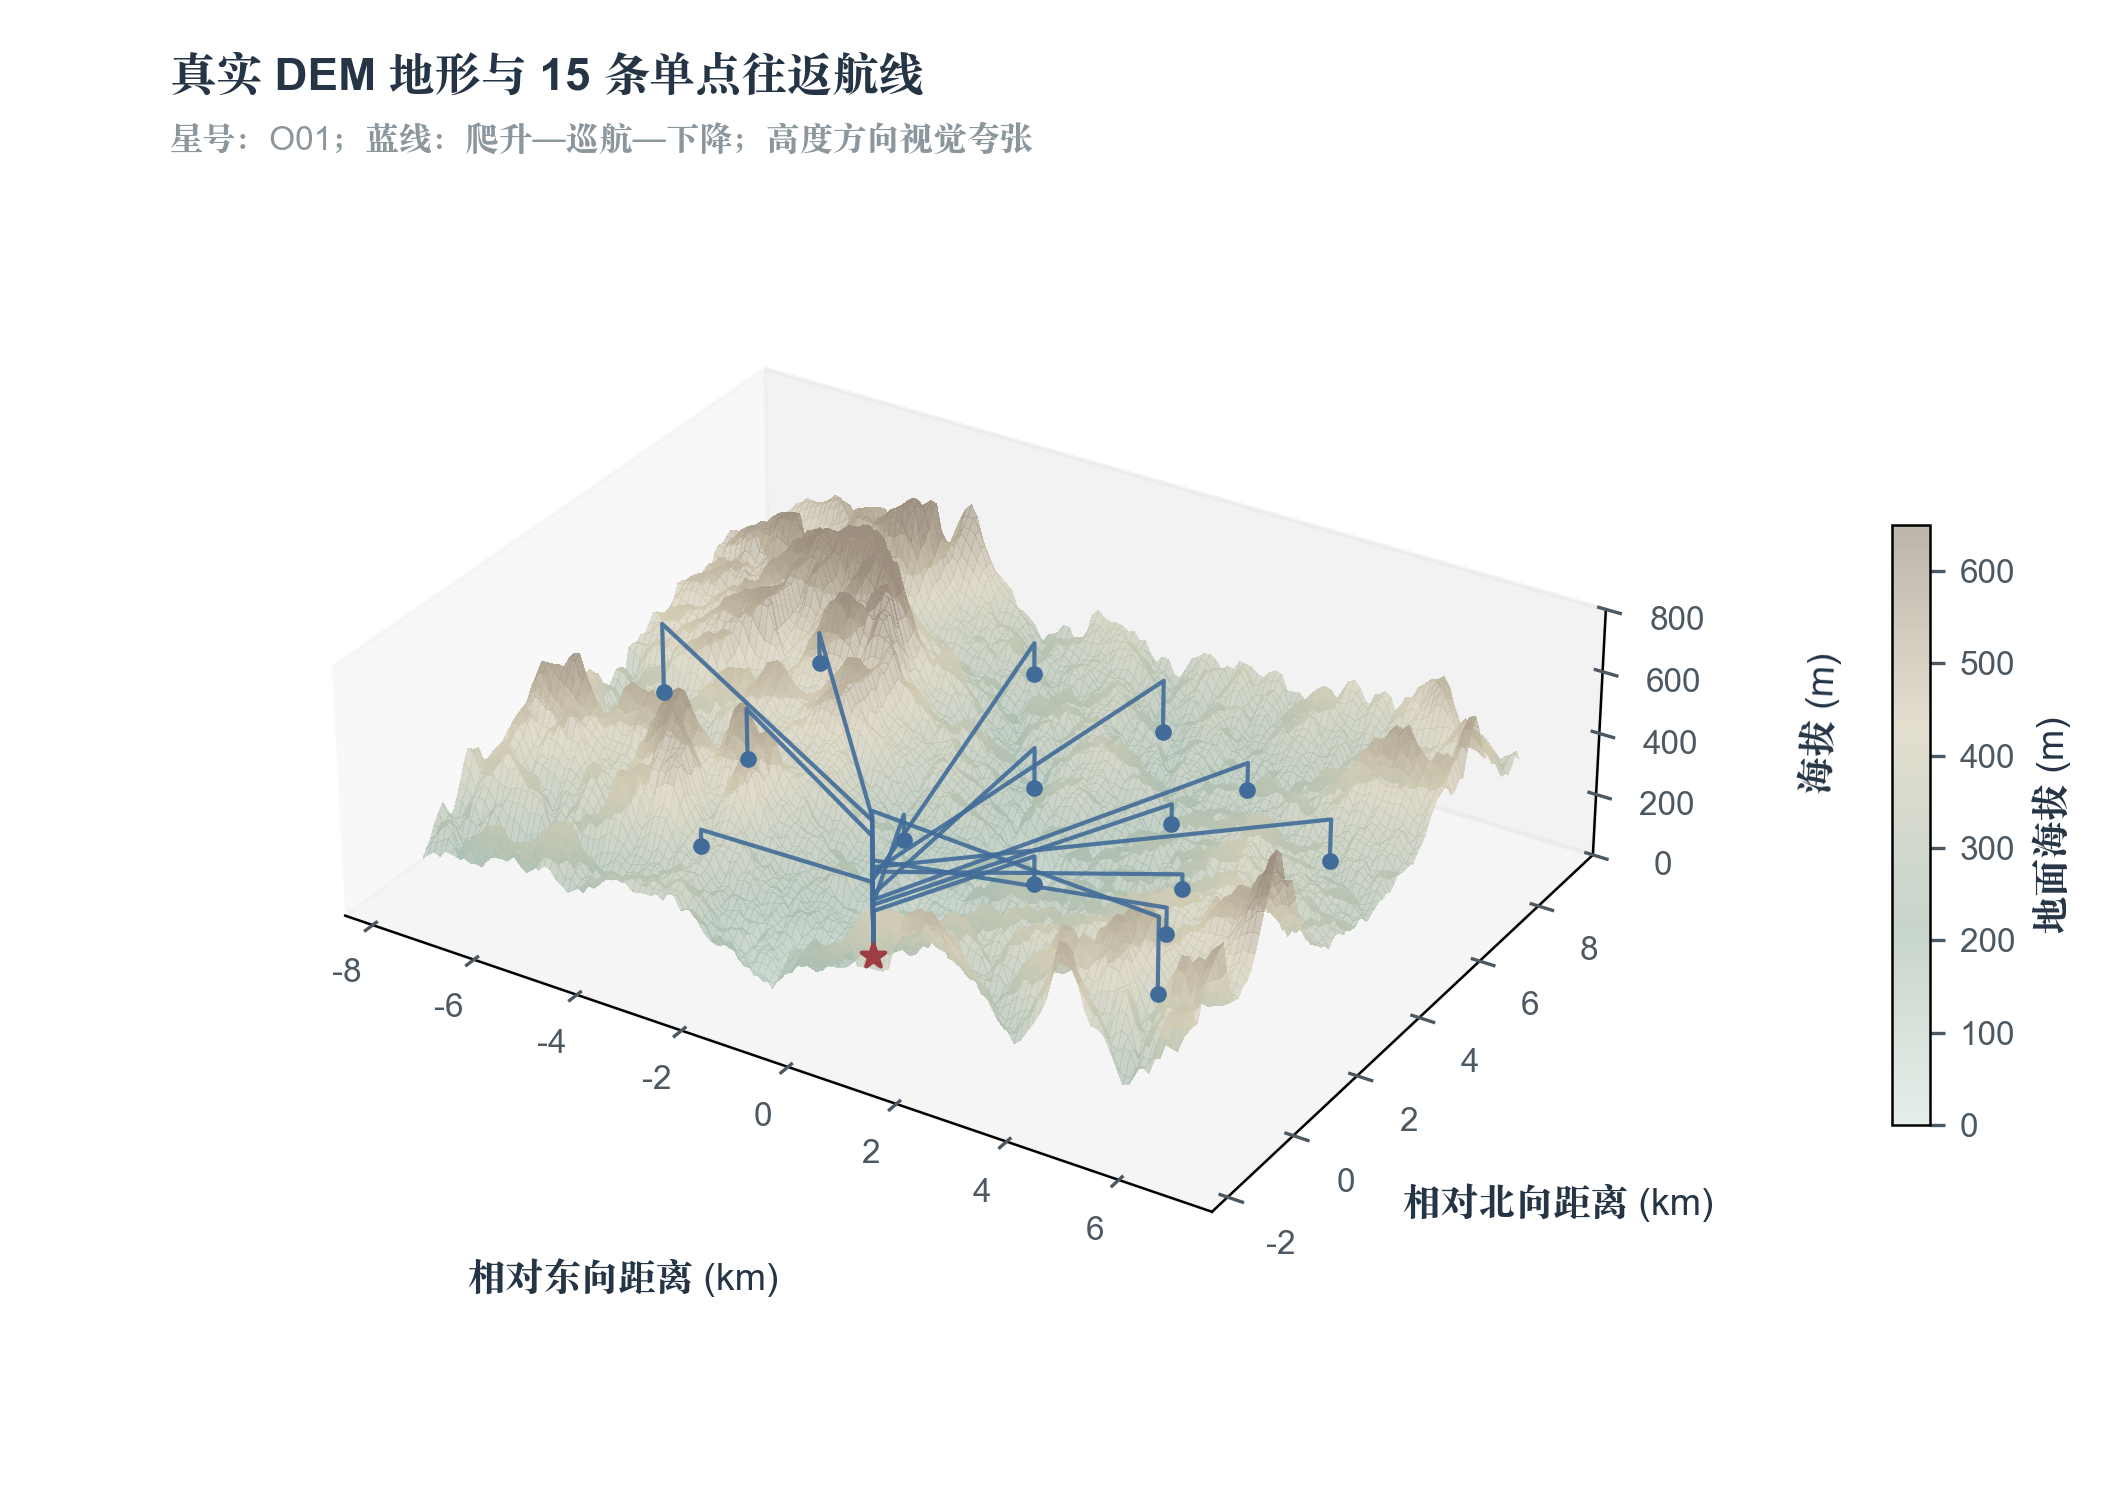

In [7]:
display(Image(filename=str(HERE.parent/'Q1-latex/figures/q1_terrain3d.png'),width=900))

### 代表航段剖面

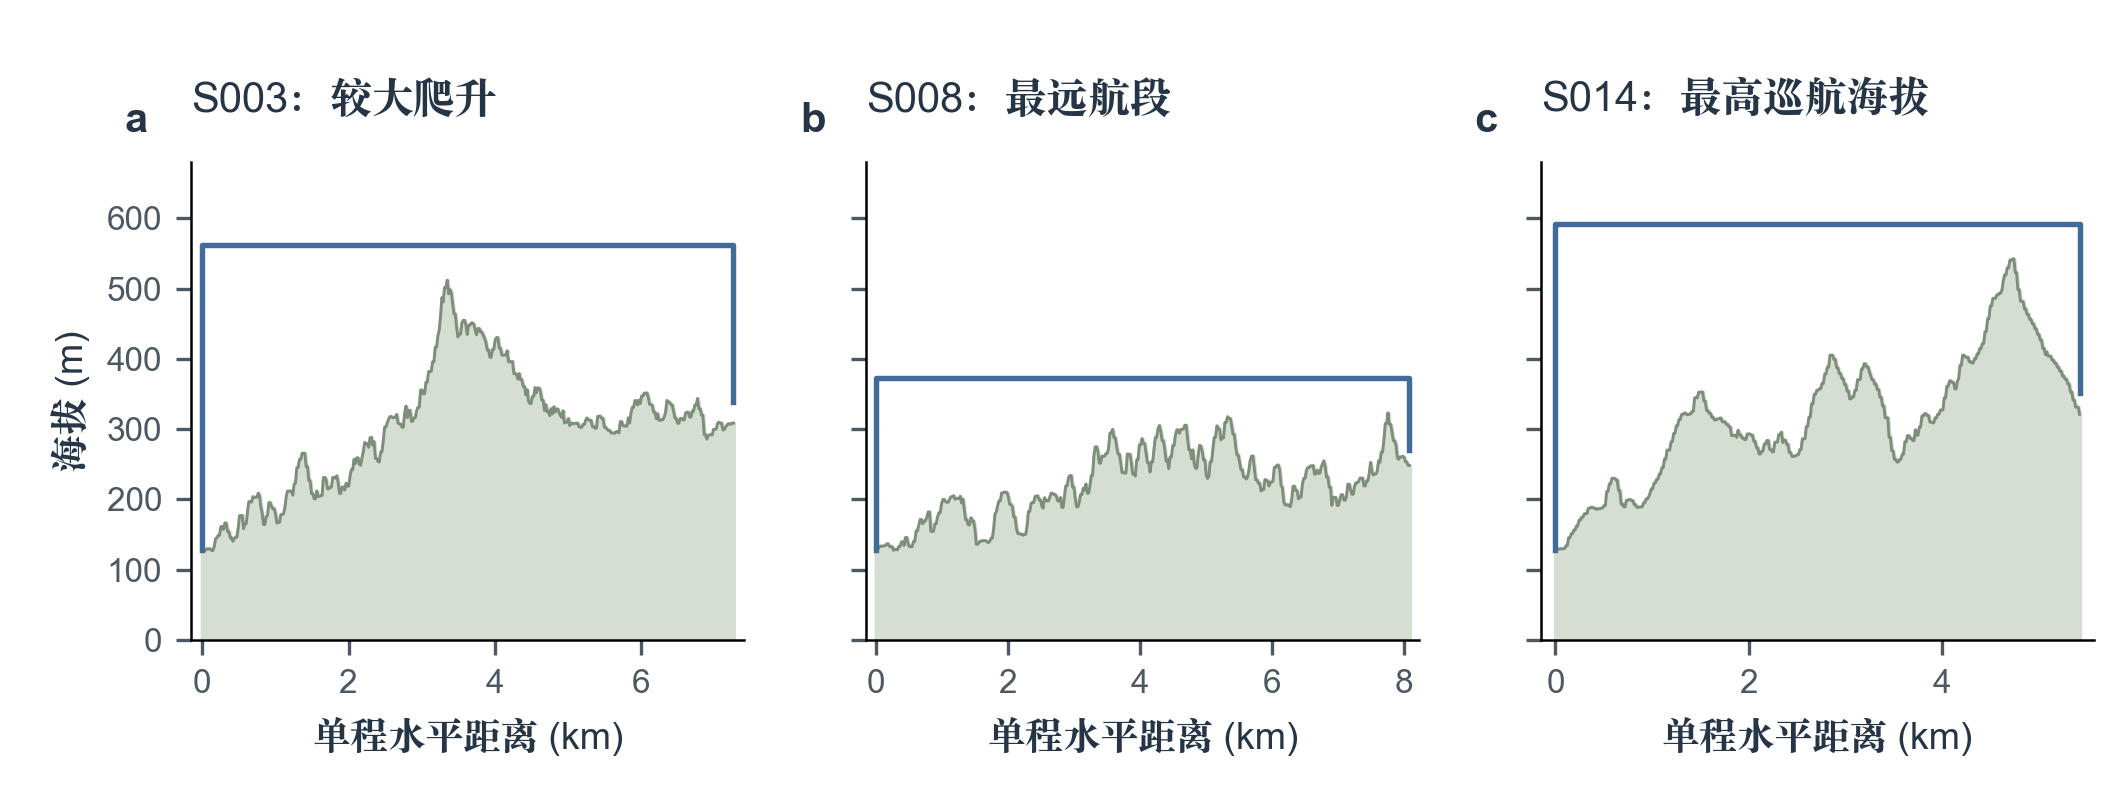

In [8]:
display(Image(filename=str(HERE.parent/'Q1-latex/figures/q1_profiles.png'),width=900))

### 最大安全载荷

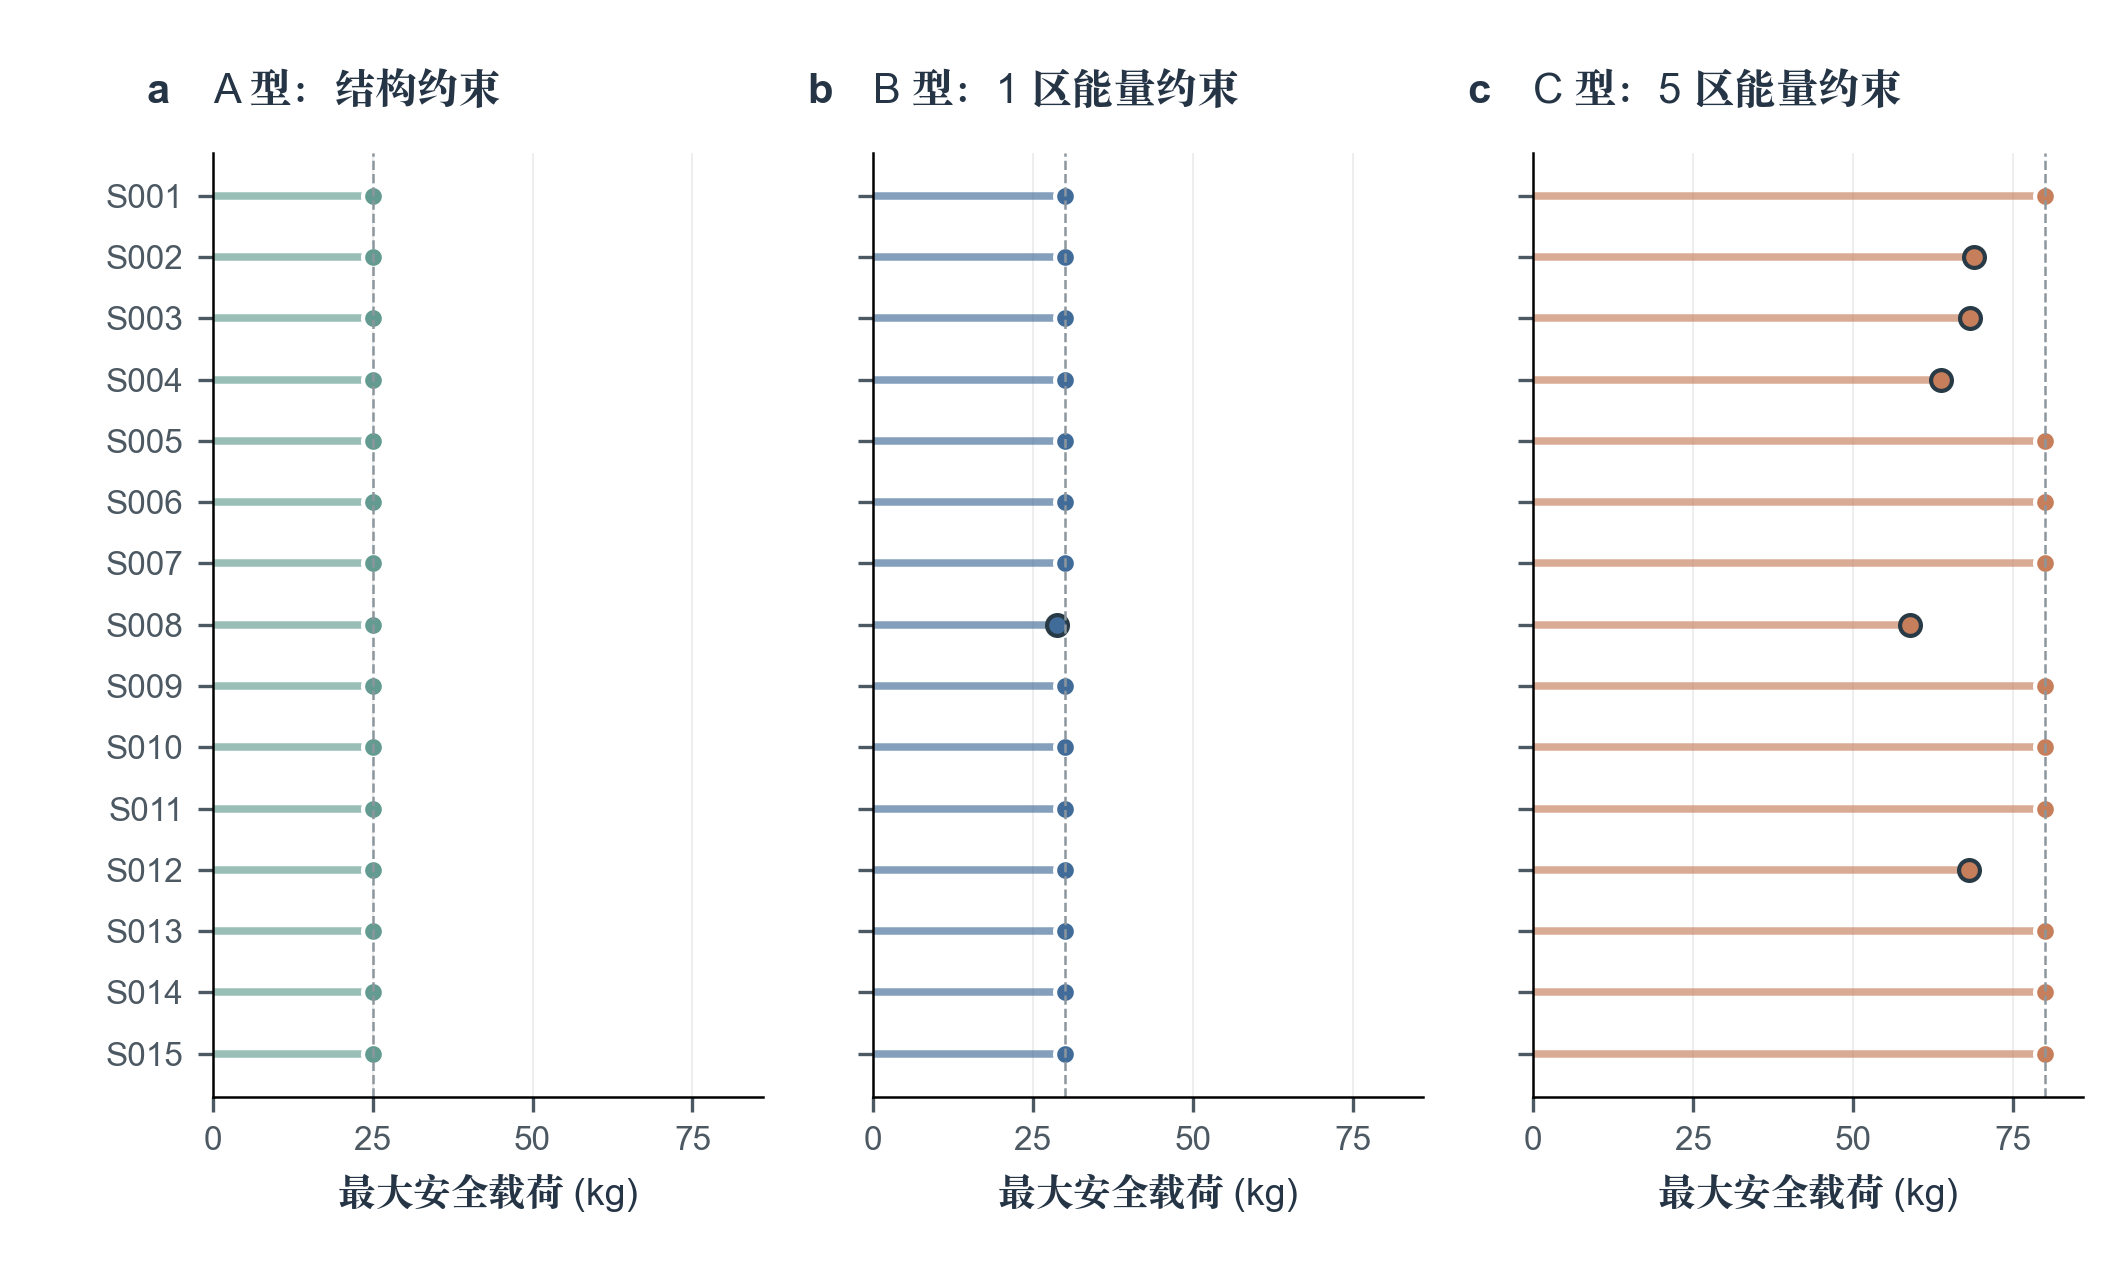

In [9]:
display(Image(filename=str(HERE.parent/'Q1-latex/figures/q1_payload.png'),width=900))

### 完整前沿与偏好切换

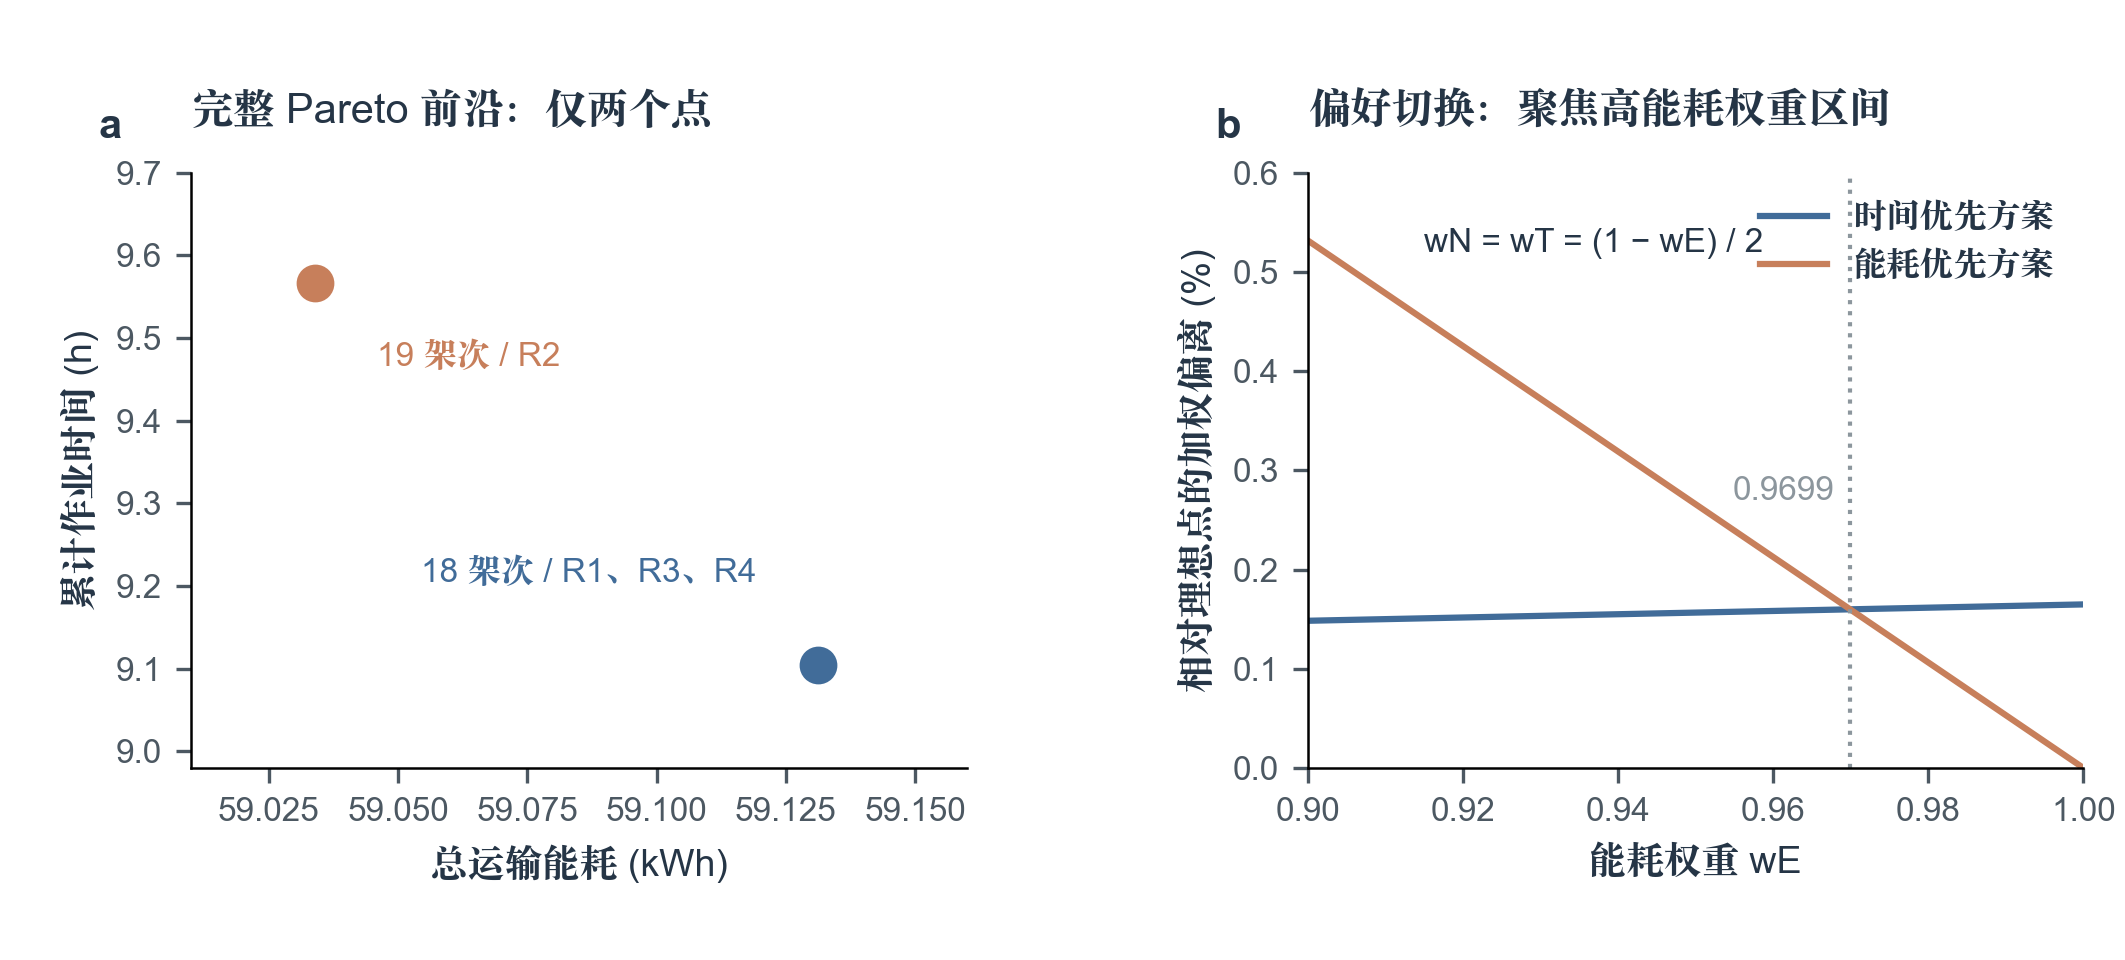

In [10]:
display(Image(filename=str(HERE.parent/'Q1-latex/figures/q1_tradeoff.png'),width=900))

### S008局部替换

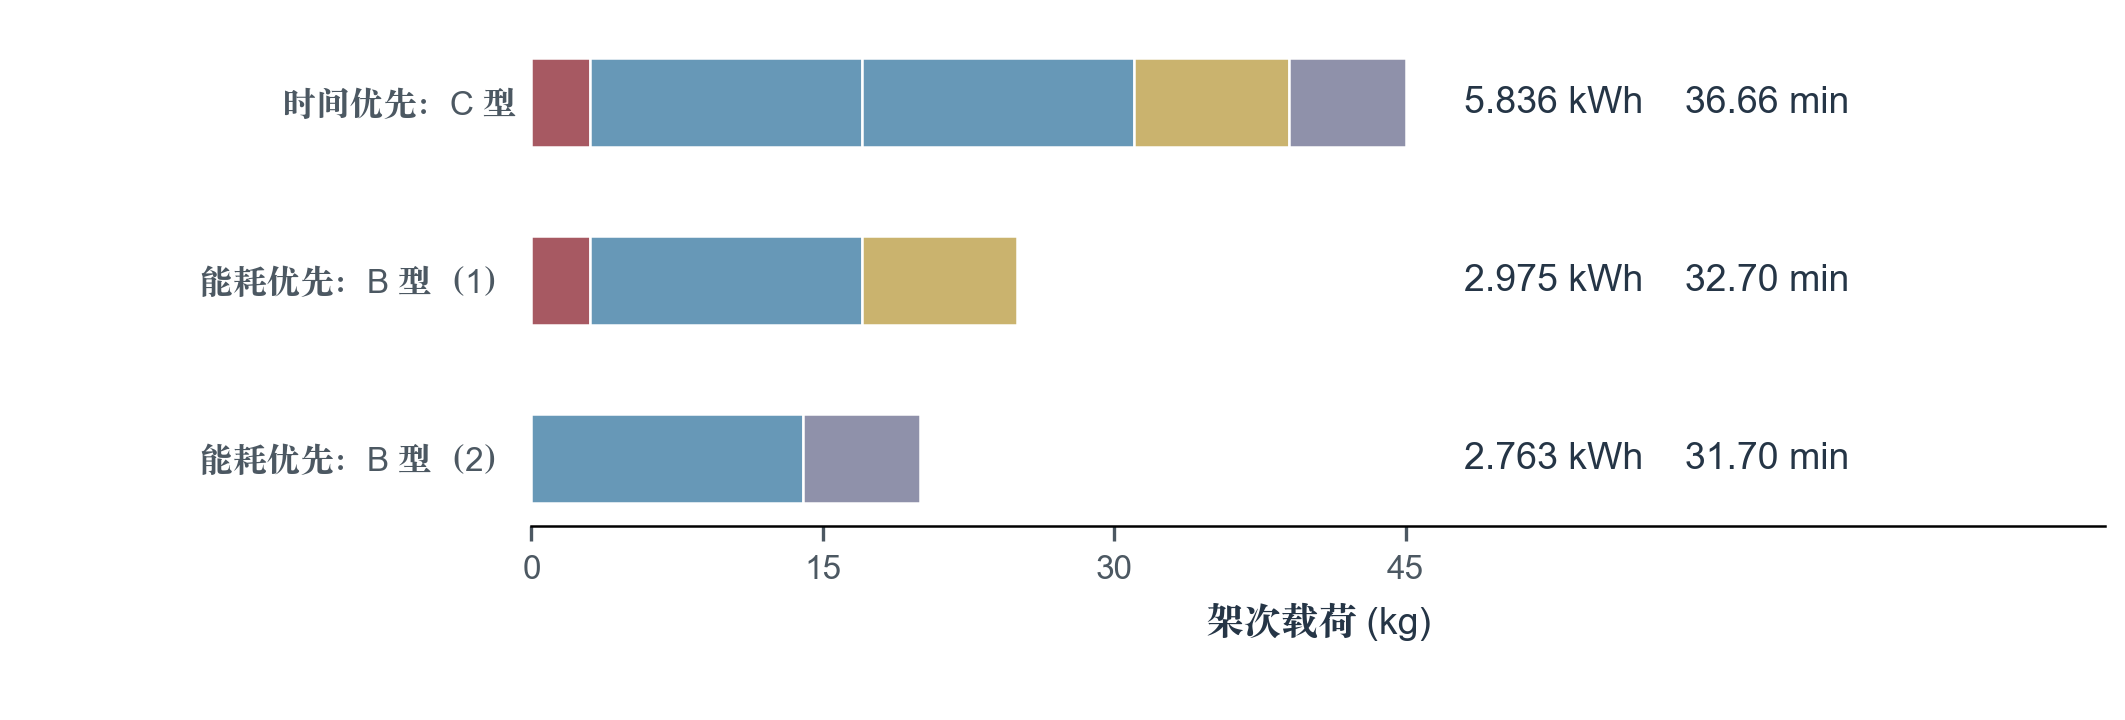

In [11]:
display(Image(filename=str(HERE.parent/'Q1-latex/figures/q1_local_tradeoff.png'),width=900))

### 逐箱装载

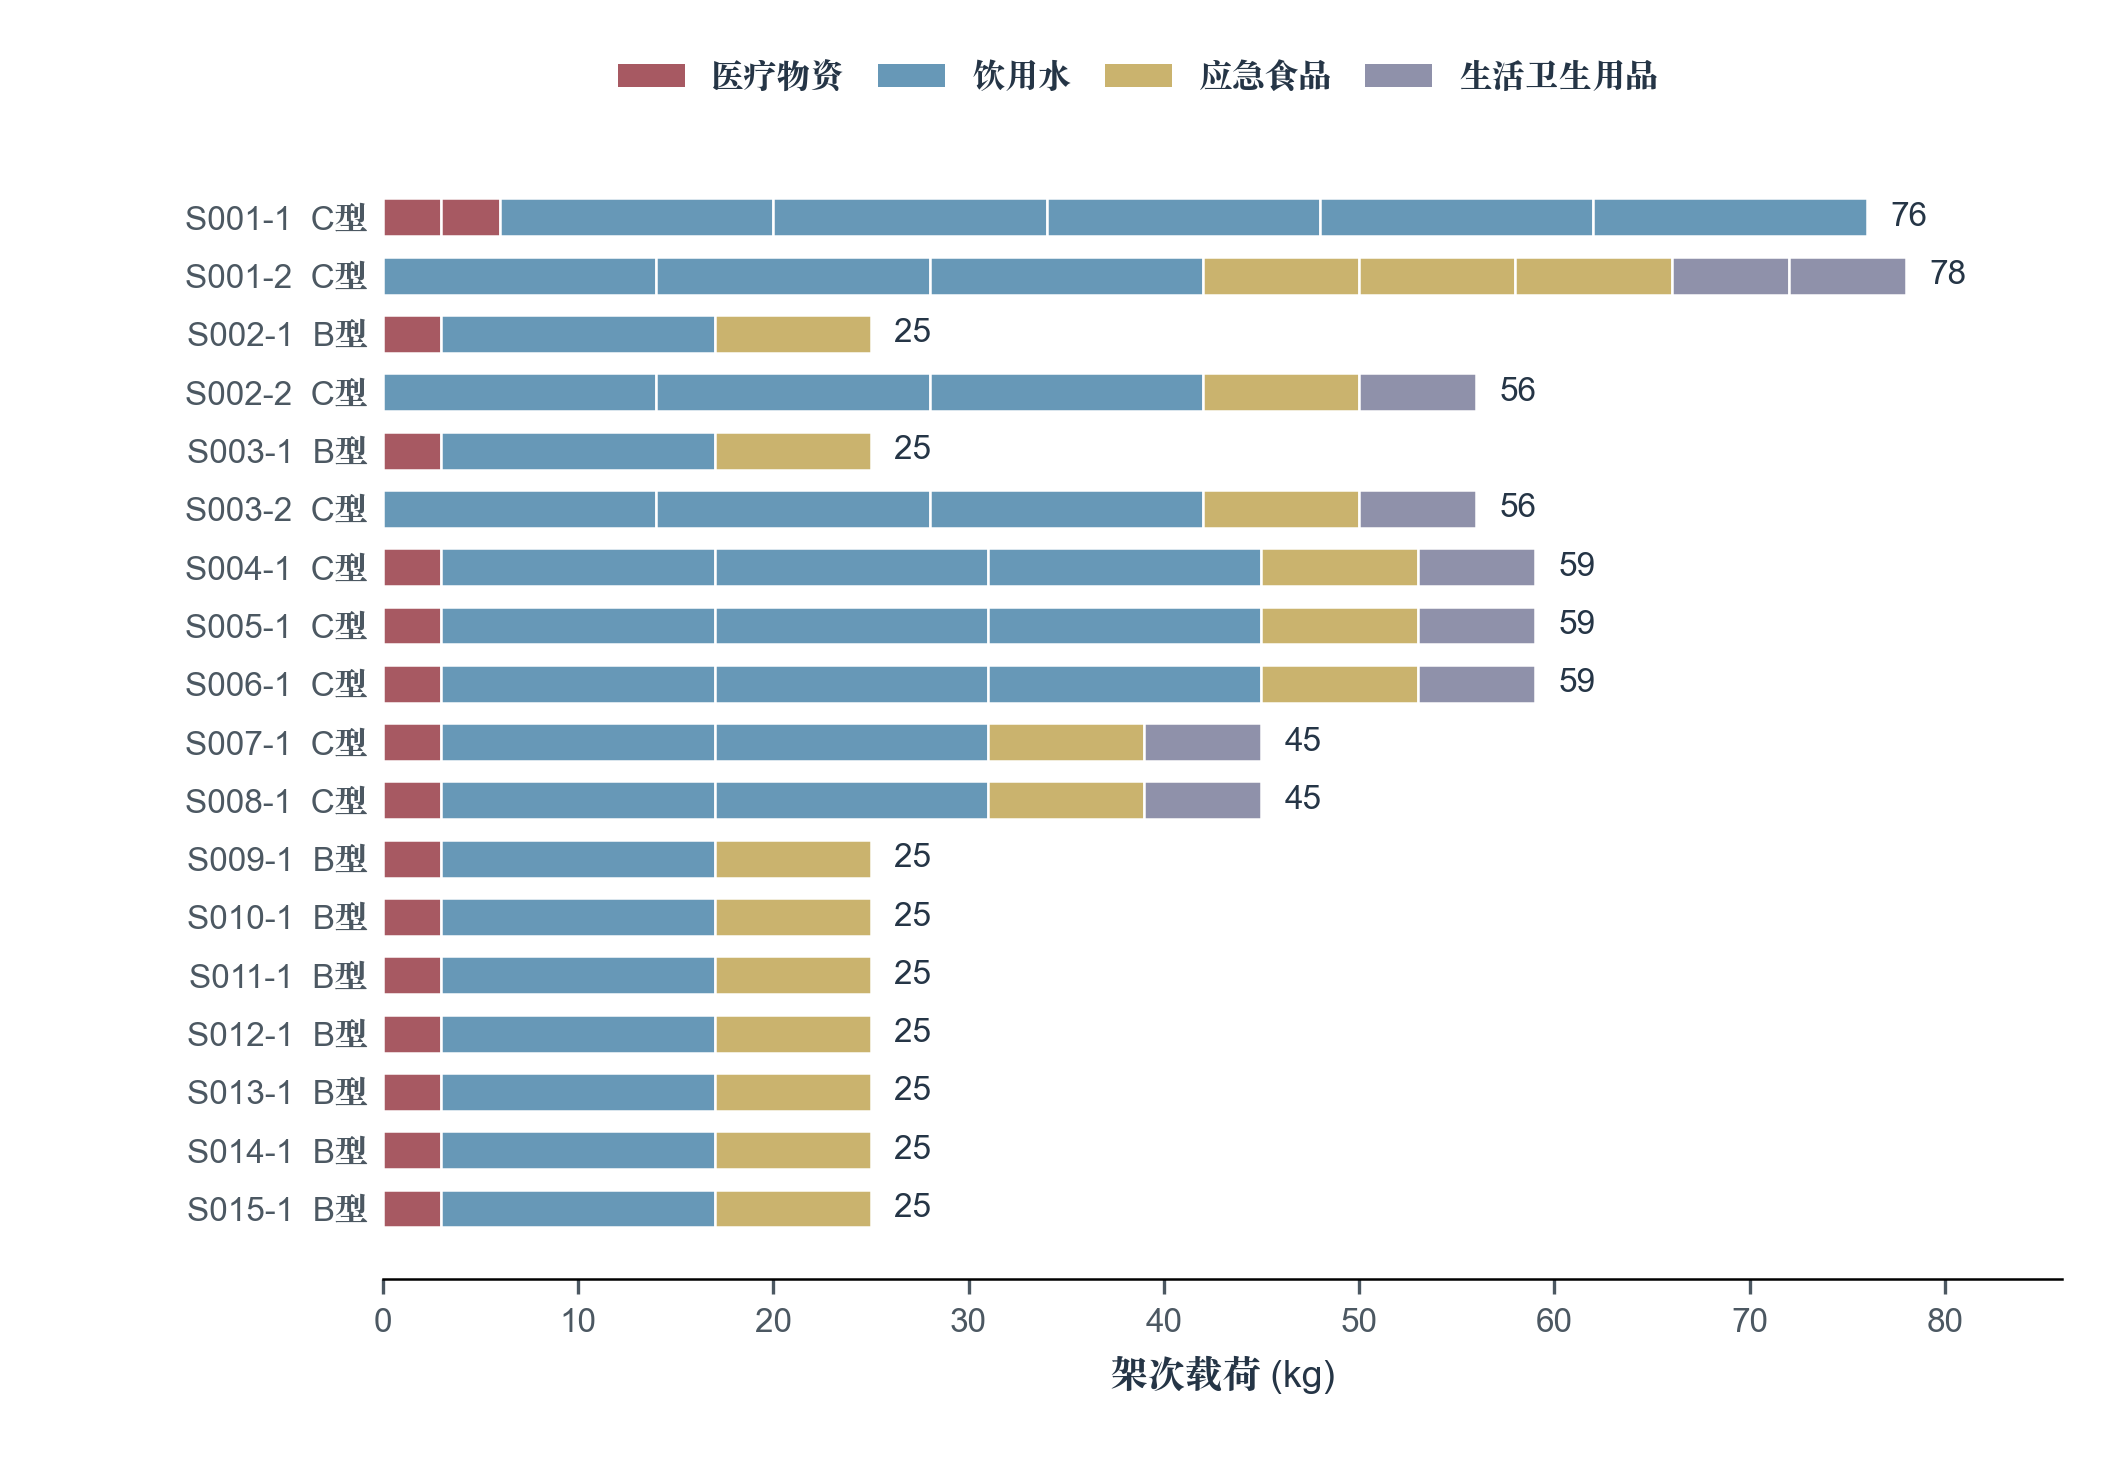

In [12]:
display(Image(filename=str(HERE.parent/'Q1-latex/figures/q1_batches.png'),width=900))

### 机型组合对照

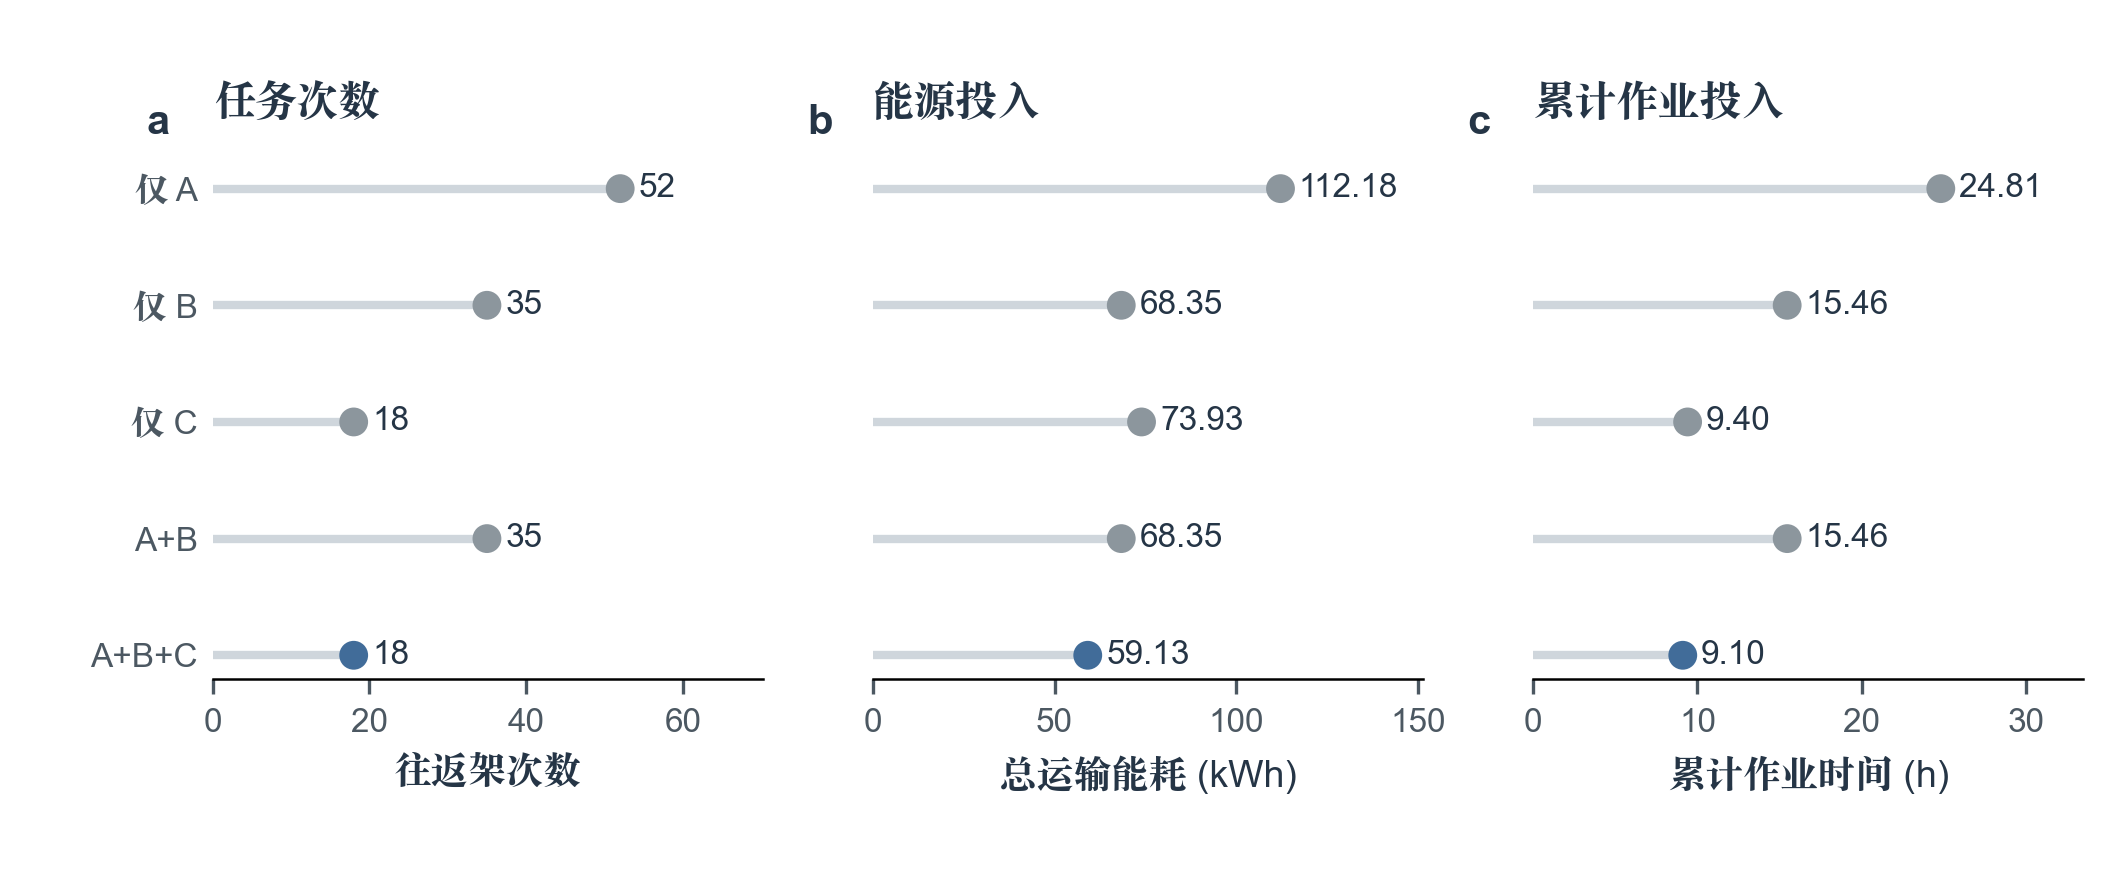

In [13]:
display(Image(filename=str(HERE.parent/'Q1-latex/figures/q1_policies.png'),width=900))

### 余量扫描

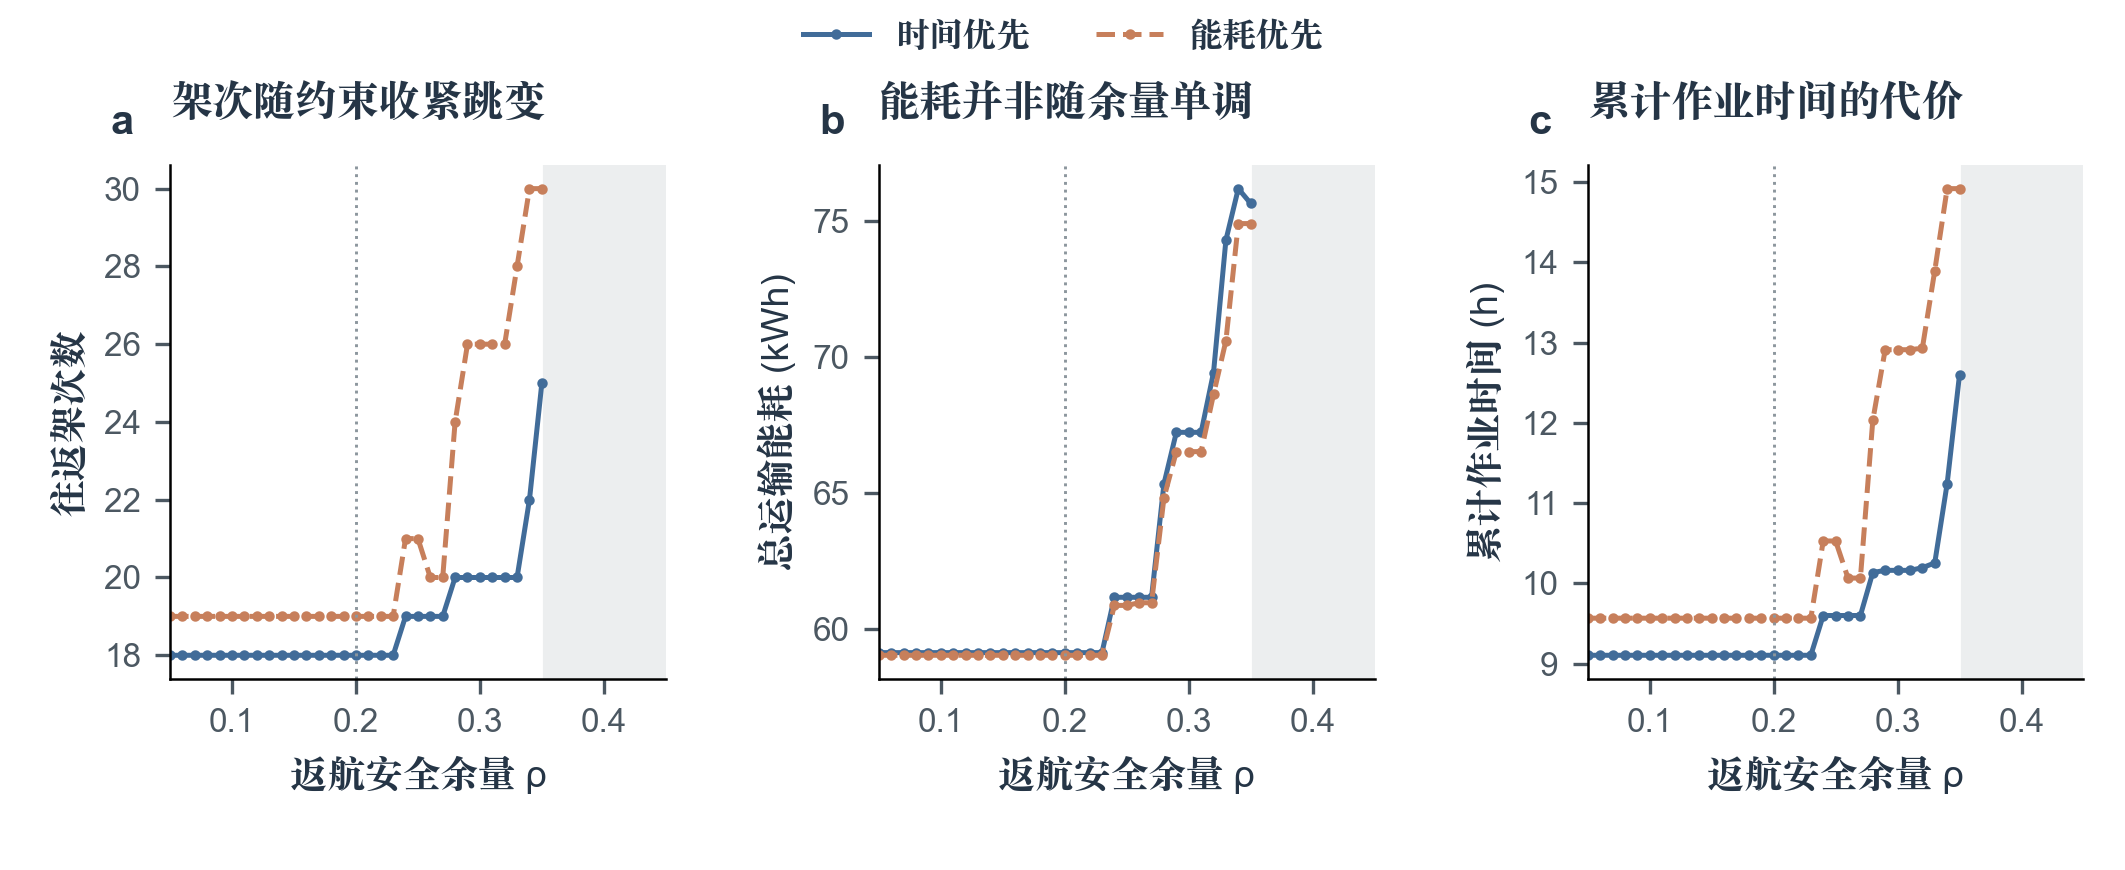

In [14]:
display(Image(filename=str(HERE.parent/'Q1-latex/figures/q1_sensitivity.png'),width=900))

### 不可拆单箱边界

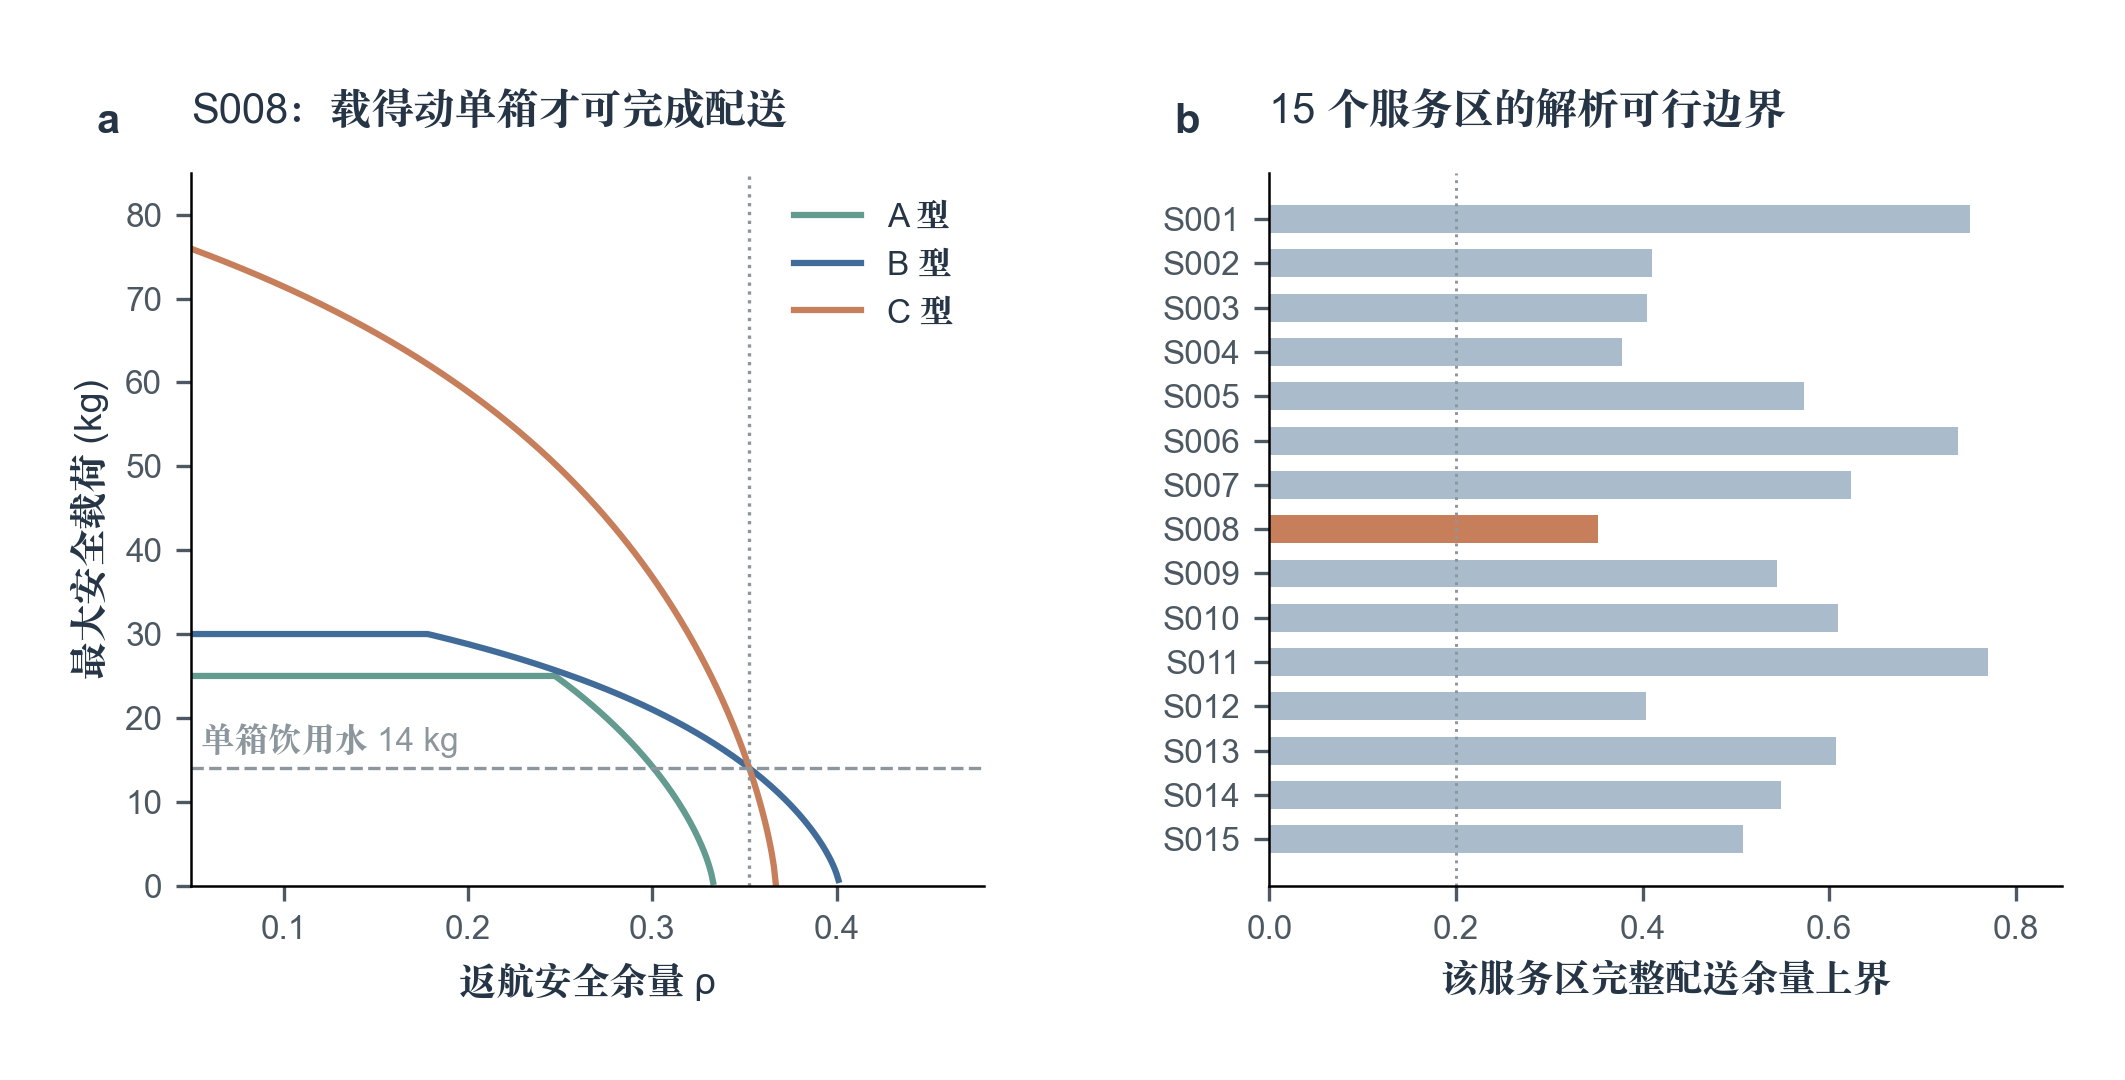

In [15]:
display(Image(filename=str(HERE.parent/'Q1-latex/figures/q1_reserve.png'),width=900))

## 6 交付
论文入口：`../Q1-latex/Q1.tex`；正文：`chapter.tex`；图片：`figures/`；表格：`tables/`。由LaTeX编译检查最终页面，不以Notebook显示替代版面质检。完整运行、输入输出、验证证据与限制见README.md。